In [2]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import ttest_rel


# start with some U_true, in this simulation its 5 tasks x 5 parcels

In [3]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [4]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [5]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

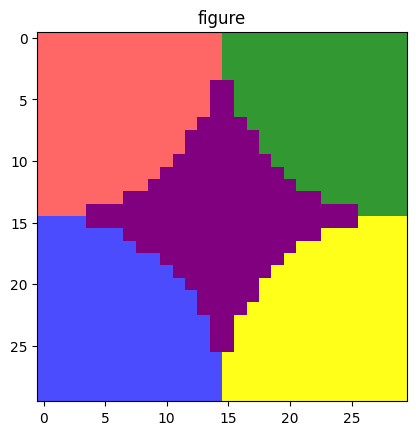

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

In [7]:
if type(U_true_5) == pt.Tensor:
    U_true_5 = U_true_5.numpy()

print(type(U_true_5))

if U_true_5.ndim == 2:
    U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])

print(U_true_5.shape)

<class 'numpy.ndarray'>
(1, 5, 900)


# Make R (parcel covariance) - in these simulations diagonal

In [8]:
R = np.diag([1, 1, 1, 1, 1])


# Simulate different scenarios for G (task covariance) to try to study metric behavior

In [9]:
def compute_correlations(n, G, R, U_true_5):
    """
    Computes correlations for different metrics over n iterations and records them in a DataFrame.

    Parameters:
        n (int): Number of iterations for different V estimation iterations.
        G (numpy.ndarray): Initial G matrix (task x task).
        R (numpy.ndarray): R matrix (parcel x parcel).
        U_true_5 (list): True values for U.

    Returns:
        pd.DataFrame: A DataFrame containing the correlation results for each iteration.
    """
    data = []

    for i in range(n):
        if i % 10 == 0:
            print(f"Iteration: {i}")

        # Find the best V
        VLib = sim.find_best_V(G=G, R=R, num_iter=1000)

        # Generate data
        Y_true = VLib @ np.array(U_true_5[0])
        G_lib = Y_true @ Y_true.T
        G_lib = np.array(G_lib)

        vtest = VLib
        ytest = Y_true

        noise = 0.4

        # Sample task batteries
        D = ut.build_combinations(G_lib, strategy='random', n_iter=100, n_tasks=3, seed=0, replacement=False)
        D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, VLib, U_true_5, sig_e=noise, vtest=vtest, ytest=ytest)

        # Compute correlations and store them in a dictionary
        iteration_data = {
            'iteration': i,
            'corr_var_perc': spearmanr(D_ev['variance'], D_ev['perc'])[0],
            'corr_log_det_perc': spearmanr(D_ev['log_det'], D_ev['perc'])[0],
            'corr_inv_trace_perc': spearmanr(D_ev['inverse_trace'], D_ev['perc'])[0],
            'corr_var_mc_perc': spearmanr(D_ev['variance_mc'], D_ev['perc'])[0],
            'corr_log_det_mc_perc': spearmanr(D_ev['log_det_mc'], D_ev['perc'])[0],
            'corr_inv_trace_mc_perc': spearmanr(D_ev['inverse_trace_mc'], D_ev['perc'])[0]
        }

        data.append(iteration_data)

    # Convert the list of dictionaries to a DataFrame
    results_df = pd.DataFrame(data)

    return results_df


In [10]:
# number of iterations
n = 100

# Sim 1 : tasks IID (G is diagonal)

In [11]:
G = np.diag([1, 1, 1, 1, 1])
results_1 = compute_correlations(n, G, R, U_true_5)


Iteration: 0


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning

Iteration: 10


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning

Iteration: 20


...

c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning

Iteration: 80


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning

Iteration: 90


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning

In [12]:
mean_correlations = results_1.mean()

# ttest
metrics = ['corr_var_perc', 'corr_log_det_perc', 'corr_inv_trace_perc', 'corr_var_mc_perc', 'corr_log_det_mc_perc','corr_inv_trace_mc_perc']
p_values = {}

for i, metric_1 in enumerate(metrics):
    for metric_2 in metrics[i + 1:]:
        t_stat, p_val = ttest_rel(results_1[metric_1], results_1[metric_2], nan_policy='omit')
        p_values[f"{metric_1} vs {metric_2}"] = p_val


mean_df = pd.DataFrame(mean_correlations, columns=['Mean'])
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Comparison', 'p-value'])

# Print results
print("Mean Correlations:")
print(mean_df)
print("\nSignificance Testing (Paired t-tests):")
print(p_values_df)


Mean Correlations:
                             Mean
iteration               49.500000
corr_var_perc            0.033138
corr_log_det_perc        0.023590
corr_inv_trace_perc      0.023101
corr_var_mc_perc         0.040694
corr_log_det_mc_perc     0.029904
corr_inv_trace_mc_perc   0.041367

Significance Testing (Paired t-tests):
                                        Comparison   p-value
0               corr_var_perc vs corr_log_det_perc  0.982954
1             corr_var_perc vs corr_inv_trace_perc  0.495461
2                corr_var_perc vs corr_var_mc_perc  0.793201
3            corr_var_perc vs corr_log_det_mc_perc  0.353476
4          corr_var_perc vs corr_inv_trace_mc_perc  0.771869
5         corr_log_det_perc vs corr_inv_trace_perc  0.908538
6            corr_log_det_perc vs corr_var_mc_perc  0.844707
7        corr_log_det_perc vs corr_log_det_mc_perc  0.453878
8      corr_log_det_perc vs corr_inv_trace_mc_perc  0.776721
9          corr_inv_trace_perc vs corr_var_mc_perc  0.52844

none of the metrics are informative (because no information in diagonal or off diagonal of G) and no significant differences between them..

# Sim 2: no correaltions, differences in diagonal. Prediction: all metrics would be useful

In [13]:
G = np.diag([0.9, 0.7, 0.2, 0.3, 0.5])
results_2 = compute_correlations(n, G, R, U_true_5)

Iteration: 0
Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40
Iteration: 50
Iteration: 60
Iteration: 70
Iteration: 80
Iteration: 90


In [14]:
mean_correlations = results_2.mean()

# ttest
metrics = ['corr_var_perc', 'corr_log_det_perc', 'corr_inv_trace_perc', 'corr_var_mc_perc', 'corr_log_det_mc_perc','corr_inv_trace_mc_perc']
p_values = {}

for i, metric_1 in enumerate(metrics):
    for metric_2 in metrics[i + 1:]:
        t_stat, p_val = ttest_rel(results_2[metric_1], results_2[metric_2], nan_policy='omit')
        p_values[f"{metric_1} vs {metric_2}"] = p_val


mean_df = pd.DataFrame(mean_correlations, columns=['Mean'])
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Comparison', 'p-value'])

# Print results
print("Mean Correlations:")
print(mean_df)
print("\nSignificance Testing (Paired t-tests):")
print(p_values_df)


Mean Correlations:
                             Mean
iteration               49.500000
corr_var_perc            0.623779
corr_log_det_perc        0.600121
corr_inv_trace_perc      0.572364
corr_var_mc_perc         0.624529
corr_log_det_mc_perc     0.624000
corr_inv_trace_mc_perc   0.609697

Significance Testing (Paired t-tests):
                                        Comparison       p-value
0               corr_var_perc vs corr_log_det_perc  3.835455e-03
1             corr_var_perc vs corr_inv_trace_perc  5.594112e-05
2                corr_var_perc vs corr_var_mc_perc  6.352198e-01
3            corr_var_perc vs corr_log_det_mc_perc  9.464730e-01
4          corr_var_perc vs corr_inv_trace_mc_perc  4.341823e-02
5         corr_log_det_perc vs corr_inv_trace_perc  7.147569e-08
6            corr_log_det_perc vs corr_var_mc_perc  2.383114e-03
7        corr_log_det_perc vs corr_log_det_mc_perc  5.333406e-04
8      corr_log_det_perc vs corr_inv_trace_mc_perc  5.268082e-02
9          corr_inv

all metrics utilize information in the diagonal of G small differences?..

# Sim 3: constant diagonal, correlations on the off-diagonal

In [15]:
G = np.array([[1, 0.3, 0.2, 0.1 ,0.3],
                [0.3, 1, 0.5, 0.4, 0.3],
                [0.2, 0.5, 1, 0.1, 0.4],
                [0.1, 0.4, 0.1, 1, 0.5],
                [0.3, 0.3, 0.4, 0.5, 1]])

results_3 = compute_correlations(n, G, R, U_true_5)

Iteration: 0
Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40
Iteration: 50
Iteration: 60
Iteration: 70
Iteration: 80
Iteration: 90


In [16]:
mean_correlations = results_3.mean()

# ttest
metrics = ['corr_var_perc', 'corr_log_det_perc', 'corr_inv_trace_perc', 'corr_var_mc_perc', 'corr_log_det_mc_perc','corr_inv_trace_mc_perc']
p_values = {}

for i, metric_1 in enumerate(metrics):
    for metric_2 in metrics[i + 1:]:
        t_stat, p_val = ttest_rel(results_3[metric_1], results_3[metric_2], nan_policy='omit')
        p_values[f"{metric_1} vs {metric_2}"] = p_val


mean_df = pd.DataFrame(mean_correlations, columns=['Mean'])
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Comparison', 'p-value'])

# Print results
print("Mean Correlations:")
print(mean_df)
print("\nSignificance Testing (Paired t-tests):")
print(p_values_df)



Mean Correlations:
                             Mean
iteration               49.500000
corr_var_perc            0.077667
corr_log_det_perc        0.325964
corr_inv_trace_perc      0.304368
corr_var_mc_perc         0.301940
corr_log_det_mc_perc     0.333465
corr_inv_trace_mc_perc   0.329498

Significance Testing (Paired t-tests):
                                        Comparison   p-value
0               corr_var_perc vs corr_log_det_perc  0.000003
1             corr_var_perc vs corr_inv_trace_perc  0.000031
2                corr_var_perc vs corr_var_mc_perc  0.000005
3            corr_var_perc vs corr_log_det_mc_perc  0.000001
4          corr_var_perc vs corr_inv_trace_mc_perc  0.000002
5         corr_log_det_perc vs corr_inv_trace_perc  0.078026
6            corr_log_det_perc vs corr_var_mc_perc  0.200737
7        corr_log_det_perc vs corr_log_det_mc_perc  0.414741
8      corr_log_det_perc vs corr_inv_trace_mc_perc  0.607265
9          corr_inv_trace_perc vs corr_var_mc_perc  0.92616

when no information in the diagonal of G, but correlations exist in the off-diagonal -> uncentered variance is useless but the others are useful because they all have info from the off-diagonal

# Sim 4: differences in both diagonal and off-diagonal

In [17]:
G = np.array([[0.9, 0.45, 0.36, 0.41, 0.46],
            [0.45, 0.55, 0.4, 0.47, 0.45],
            [0.36, 0.4, 0.6, 0.35, 0.35],
            [0.41, 0.47, 0.35, 0.7, 0.45],
            [0.46, 0.45, 0.35, 0.45, 0.6]])

results_4 = compute_correlations(n, G, R, U_true_5)



Iteration: 0
Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40
Iteration: 50
Iteration: 60
Iteration: 70
Iteration: 80
Iteration: 90


In [18]:
mean_correlations = results_4.mean()

# ttest
metrics = ['corr_var_perc', 'corr_log_det_perc', 'corr_inv_trace_perc', 'corr_var_mc_perc', 'corr_log_det_mc_perc','corr_inv_trace_mc_perc']
p_values = {}

for i, metric_1 in enumerate(metrics):
    for metric_2 in metrics[i + 1:]:
        t_stat, p_val = ttest_rel(results_4[metric_1], results_4[metric_2], nan_policy='omit')
        p_values[f"{metric_1} vs {metric_2}"] = p_val


mean_df = pd.DataFrame(mean_correlations, columns=['Mean'])
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Comparison', 'p-value'])

# Print results
print("Mean Correlations:")
print(mean_df)
print("\nSignificance Testing (Paired t-tests):")
print(p_values_df)


Mean Correlations:
                             Mean
iteration               49.500000
corr_var_perc            0.473846
corr_log_det_perc        0.563030
corr_inv_trace_perc      0.556242
corr_var_mc_perc         0.563030
corr_log_det_mc_perc     0.563879
corr_inv_trace_mc_perc   0.556242

Significance Testing (Paired t-tests):
                                        Comparison   p-value
0               corr_var_perc vs corr_log_det_perc  0.000005
1             corr_var_perc vs corr_inv_trace_perc  0.000428
2                corr_var_perc vs corr_var_mc_perc  0.000005
3            corr_var_perc vs corr_log_det_mc_perc  0.000082
4          corr_var_perc vs corr_inv_trace_mc_perc  0.000428
5         corr_log_det_perc vs corr_inv_trace_perc  0.460305
6            corr_log_det_perc vs corr_var_mc_perc       NaN
7        corr_log_det_perc vs corr_log_det_mc_perc  0.872254
8      corr_log_det_perc vs corr_inv_trace_mc_perc  0.460305
9          corr_inv_trace_perc vs corr_var_mc_perc  0.46030

when you maintain correlations in the off-diagonal, but also have differences in the diagonal, uncentered varaince becomes useful again but not to the same extent as the others (because it doesn't have information from the off-diagonal)